In [1]:
import os
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.cluster import KMeans
from transformers import Qwen2_5_VLForConditionalGeneration, AutoTokenizer, AutoProcessor
from qwen_vl_utils import process_vision_info
from sklearn.model_selection import train_test_split
from transformers import CLIPModel, CLIPProcessor, AutoProcessor, AutoModel
from tqdm import tqdm

/home/ubuntu/dle-project-sprint-8/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
os.environ["TOKENIZERS_PARALLELISM"] = "false"
DATA_ROOT = "data/"      
CHECKPOINT_DIR = "checkpoints/"    
CSV_PATH = os.path.join(DATA_ROOT, "data.csv")
IMAGES_DIR = os.path.join(DATA_ROOT, "data/")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [3]:
def plot_images(images_list, titles=None, scores=None, cols=5, save_path=None):
    """
    Визуализация списка изображений
    """
    n = len(images_list)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
    axes = axes.flatten() if rows*cols > 1 else [axes]
    for i, ax in enumerate(axes):
        if i < n:
            ax.imshow(images_list[i])
            if titles and i < len(titles):
                ax.set_title(titles[i], fontsize=10)
            if scores and i < len(scores):
                ax.set_xlabel(f"score: {scores[i]:.2f}", fontsize=9)
            ax.axis('off')
        else:
            ax.axis('off')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

def simple_json_parse(json_data):
    """Очистка строки от markdown и парсинг JSON"""
    if isinstance(json_data, list):
        json_str = json_data[0]
    else:
        json_str = json_data
    json_str = json_str.replace('```json', '').replace('```', '').strip()
    return json.loads(json_str)


# Этап 1: Работа с данными

## Загрузка и первичный анализ

In [4]:
df = pd.read_csv(CSV_PATH)
print(f"Original dataset size: {len(df)}")

Original dataset size: 44441


In [5]:
df.sample(5)

,image,description,display name,category
15640,22319.jpg,Composition Beige boat neck t-shirt made of 70...,Wildcraft Women Cream Kimono Top,Tops
39217,54395.jpg,Olive green single fold wallet crafted from sy...,Baggit Women Olive Wallet,Wallets
5542,24293.jpg,It's comfort unparalleled once you slip into t...,Quiksilver Men High Grey Socks,Socks
27491,29161.jpg,Wash care Dry clean preferred Hand wash in col...,United Colors of Benetton Men Red T-shirt,Tshirts
29425,10397.jpg,"Stylish and comfortable, this motorsport inspi...",Puma Men Slick Gents 3 Black Watches,Watches


In [6]:
print(f"Num categories: {df.category.nunique()}")

Num categories: 142


In [7]:
# Удаляем дубликаты и пустые строки
df = df.drop_duplicates(subset=['image', 'description'])
df = df.dropna(subset=['image', 'description'])
df = df.reset_index(drop=True)

print(f"After cleaning: {len(df)}")

After cleaning: 44160


In [8]:
print(f"Всего файлов в папке images: {len(os.listdir(IMAGES_DIR))}")

Всего файлов в папке images: 8175


In [9]:
# Проверим существование файлов изображений
valid_rows = []
for idx, row in df.iterrows():
    img_path = os.path.join(IMAGES_DIR, row['image'])
    if os.path.exists(img_path):
        valid_rows.append(idx)
        
df = df.loc[valid_rows].reset_index(drop=True)

print(f"After checking image files: {len(df)}")

After checking image files: 8168


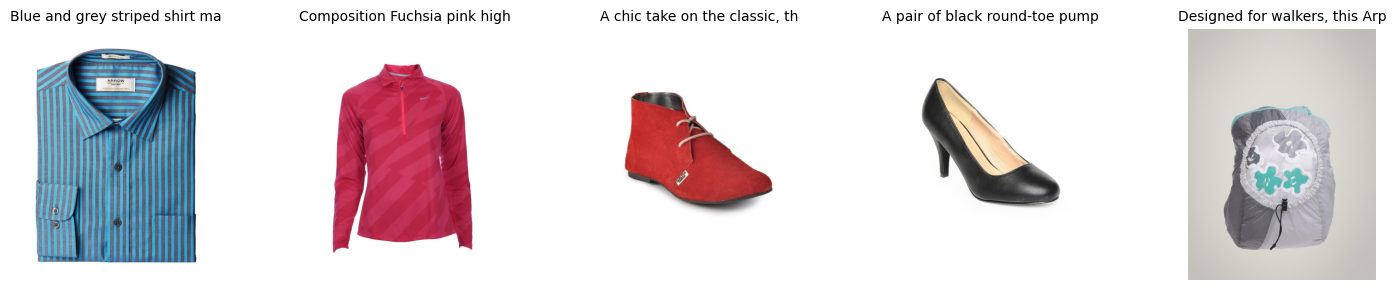

In [10]:
# Визуализируем 5 случайных примеров
sample = df.sample(5)

sample_images = [Image.open(os.path.join(IMAGES_DIR, row['image'])) for _, row in sample.iterrows()]
sample_titles = [row['description'][:30] for _, row in sample.iterrows()]
plot_images(sample_images, titles=sample_titles, cols=5)

In [11]:
resolutions = []

for _, row in df.sample(100).iterrows():
    img = Image.open(os.path.join(IMAGES_DIR, row['image']))
    resolutions.append(img.size)
unique_res = set(resolutions)

print(f"Разрешения картинок (выборка 100): {sorted(unique_res)}")

Разрешения картинок (выборка 100): [(1080, 1440)]


- Всего записей: 44160
- Уникальных категорий: 141
- Примеры описаний:
  - Round toed, black sports shoes with red accents, low top styling and central lace-ups Leather upper ...
  - Style Note Built with the breathability and zero-distraction Fit that athletes demand, these boardsh...
  - Teal  handbag that has stitch detailing with a pleated and panel design on the front One main zipped...
- Качество описаний: в целом соответствуют картинкам, но есть шум (обнаружен KMeans).
- Разрешения варьируются, но CLIP ресайзит в 224x224.

## Предварительная оценка CLIP-скор

In [12]:
def compute_clip_scores(model, processor, df, batch_size=32):
    scores = []
    for i in tqdm(range(0, len(df), batch_size)):
        batch = df.iloc[i:i+batch_size]
        images = [Image.open(os.path.join(IMAGES_DIR, row['image'])).convert('RGB') for _, row in batch.iterrows()]
        texts = list(batch['description'])
        inputs = processor(text=texts, 
                           images=images, 
                           return_tensors="pt", 
                           padding=True,
                           max_length=77, 
                           truncation=True).to(DEVICE)
        with torch.no_grad():
            outputs = model(**inputs)
            # CLIP: косинусное сходство для правильных пар = диагональ logits_per_image
            logits = outputs.logits_per_image  # (batch, batch)
            # Нормируем через температуру (по умолчанию 100.0) -> вероятности softmax
            probs = torch.softmax(logits / 0.07, dim=1).diagonal().cpu().numpy()
            scores.extend(probs)
    return np.array(scores)

In [13]:
base_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
base_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
base_model.eval()

clip_scores = compute_clip_scores(base_model, base_processor, df.head(20))

kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(clip_scores.reshape(-1, 1))
low_score_cluster = 0 if clip_scores[labels==0].mean() < clip_scores[labels==1].mean() else 1
bad_indices = np.where(labels == low_score_cluster)[0]

print(f"Выявлено {len(bad_indices)} подозрительных пар с низким CLIP-скором (из {len(clip_scores)}).")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
100%|██████████| 1/1 [00:01<00:00,  1.19s/it]

Выявлено 4 подозрительных пар с низким CLIP-скором (из 20).


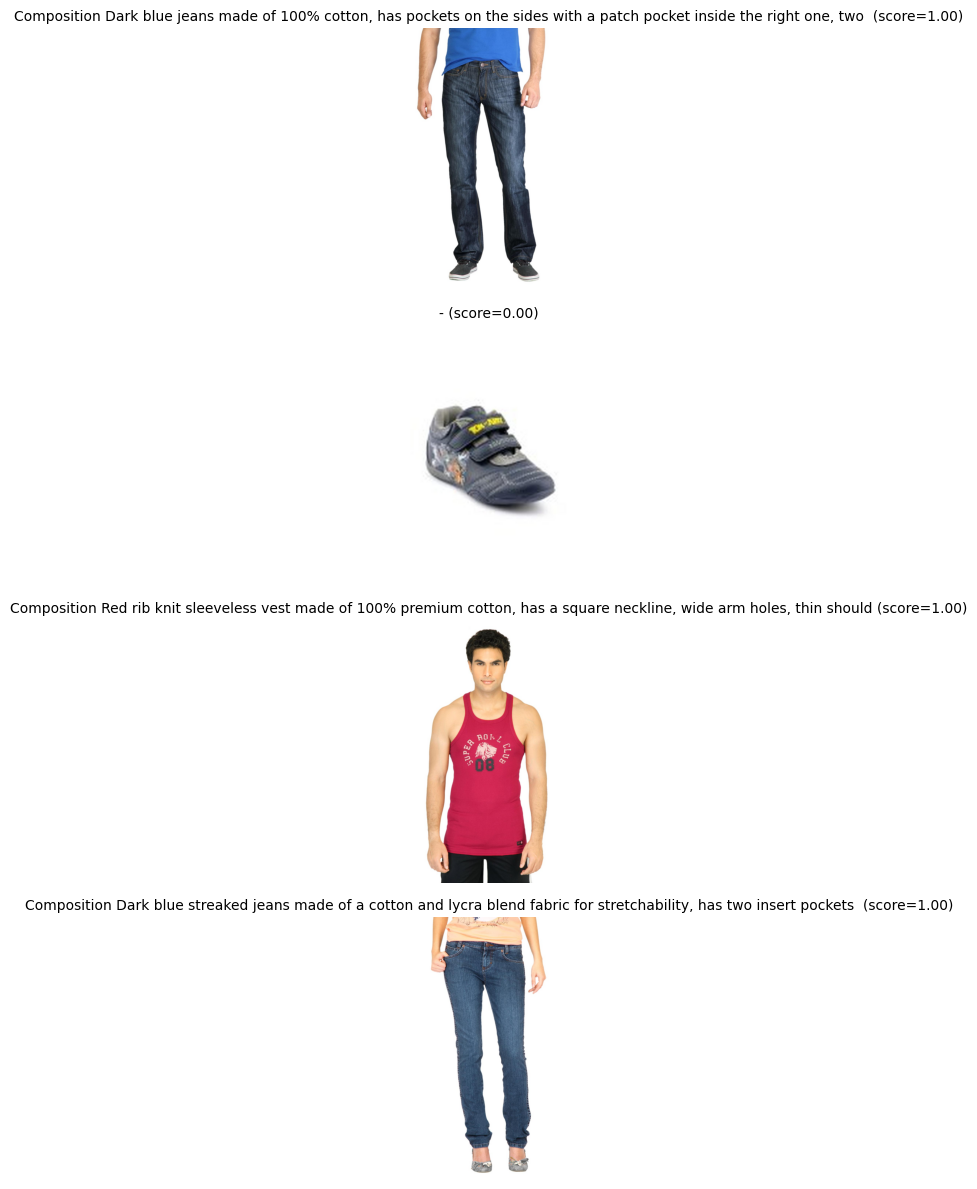

In [14]:
# Визуализируем несколько плохих пар
bad_sample = df.iloc[bad_indices[:5]]
bad_images = [Image.open(os.path.join(IMAGES_DIR, row['image'])) for _, row in bad_sample.iterrows()]
bad_titles = [f"{row['description'][:120]} (score={clip_scores[i]:.2f})" for i, (_, row) in enumerate(bad_sample.iterrows())]
plot_images(bad_images, titles=bad_titles, cols=1, save_path="bad_pairs.png")

## Разделение на train/test

In [15]:
train_df, test_df = train_test_split(df, test_size=0.1, random_state=42)
print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")

Train size: 7351, Test size: 817


## Класс Dataset

In [16]:
class FashionCLIPDataset(Dataset):
    def __init__(self, dataframe, images_dir, processor, max_length=77):
        self.dataframe = dataframe.reset_index(drop=True)
        self.images_dir = images_dir
        self.processor = processor
        self.max_length = max_length

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = os.path.join(self.images_dir, row['image'])
        image = Image.open(img_path).convert('RGB')
        text = str(row['description'])
        # Обработка через CLIPProcessor
        inputs = self.processor(text=text, images=image, return_tensors="pt",
                                padding='max_length', max_length=self.max_length, truncation=True)
        # Убираем лишние размерности
        pixel_values = inputs['pixel_values'].squeeze(0)   # (3, 224, 224)
        input_ids = inputs['input_ids'].squeeze(0)         # (77,)
        attention_mask = inputs['attention_mask'].squeeze(0)
        return {
            'pixel_values': pixel_values,
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'text': text  # для логирования
        }

In [17]:
# Процессор для CLIP
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
train_dataset = FashionCLIPDataset(train_df, IMAGES_DIR, processor)
test_dataset = FashionCLIPDataset(test_df, IMAGES_DIR, processor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

## Модель и дообучение

In [18]:
# Функция потерь уже встроена в CLIPModel, но для контроля реализуем вручную
def contrastive_loss(logits_per_image, logits_per_text):
    labels = torch.arange(len(logits_per_image), device=logits_per_image.device)
    loss_img = nn.CrossEntropyLoss()(logits_per_image, labels)
    loss_txt = nn.CrossEntropyLoss()(logits_per_text, labels)
    return (loss_img + loss_txt) / 2

# Функция валидации (средний CLIP score на тесте)
def validate(model, dataloader, processor, device):
    model.eval()
    scores = []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validation"):
            pixel_values = batch['pixel_values'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            # Прямой forward (не get_image_features)
            outputs = model(pixel_values=pixel_values, input_ids=input_ids, attention_mask=attention_mask)
            # Берём уже нормализованные эмбеддинги (CLIPModel их возвращает)
            image_embeds = outputs.image_embeds
            text_embeds = outputs.text_embeds
            # На всякий случай ещё раз нормируем
            image_embeds = image_embeds / image_embeds.norm(dim=-1, keepdim=True)
            text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)
            # Косинусное сходство правильных пар
            similarity = (image_embeds * text_embeds).sum(dim=1)
            scores.extend(similarity.cpu().numpy())
    model.train()
    return np.mean(scores) * 100

In [19]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)

# Разморозим все слои для fine-tune полностью
for param in model.parameters():
    param.requires_grad = True

optimizer = AdamW(model.parameters(), lr=5e-6, weight_decay=0.01)

Validation: 100%|██████████| 26/26 [00:13<00:00,  1.93it/s]


Epoch 1: train loss = 0.4778, train score = 28.78, val score = 28.02


Validation: 100%|██████████| 26/26 [00:13<00:00,  1.99it/s]


Epoch 2: train loss = 0.2467, train score = 29.54, val score = 29.57


Validation: 100%|██████████| 26/26 [00:13<00:00,  1.94it/s]


Epoch 3: train loss = 0.1656, train score = 30.31, val score = 30.65


Validation: 100%|██████████| 26/26 [00:13<00:00,  1.91it/s]


Epoch 4: train loss = 0.1412, train score = 30.93, val score = 29.43


Validation: 100%|██████████| 26/26 [00:12<00:00,  2.01it/s]


Epoch 5: train loss = 0.1044, train score = 31.14, val score = 29.34


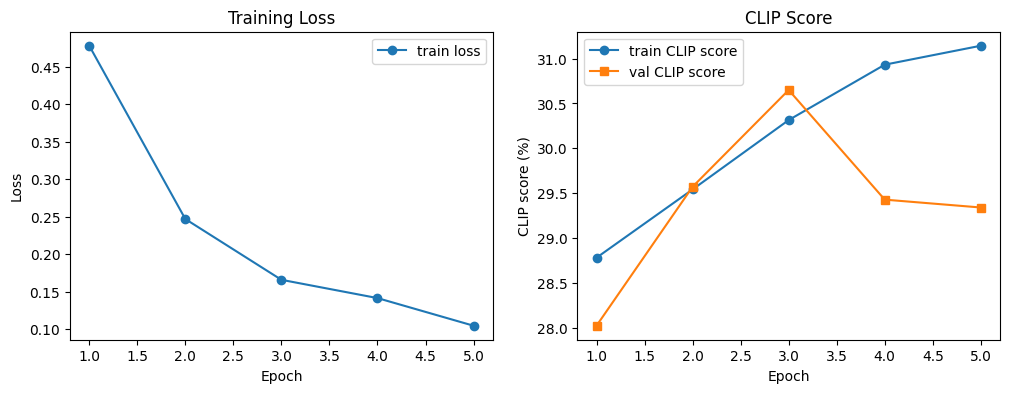

In [20]:
# Цикл обучения
num_epochs = 5
train_losses = []
train_clip_scores = []
val_clip_scores = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    epoch_score = 0
    num_batches = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for batch in progress_bar:
        pixel_values = batch['pixel_values'].to(DEVICE)
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        # forward
        outputs = model(pixel_values=pixel_values, input_ids=input_ids, attention_mask=attention_mask)
        logits_per_image = outputs.logits_per_image
        logits_per_text = outputs.logits_per_text
        loss = contrastive_loss(logits_per_image, logits_per_text)
        # обратное распространение
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # логи
        epoch_loss += loss.item()
        # CLIP score для батча
        with torch.no_grad():
            image_embeds = outputs.image_embeds
            text_embeds = outputs.text_embeds
            image_embeds = image_embeds / image_embeds.norm(dim=-1, keepdim=True)
            text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)
            batch_score = (image_embeds * text_embeds).sum(dim=1).mean().item() * 100
            epoch_score += batch_score
        num_batches += 1
        progress_bar.set_postfix({"loss": f"{loss.item():.4f}", "score": f"{batch_score:.2f}"})
    avg_loss = epoch_loss / num_batches
    avg_train_score = epoch_score / num_batches
    train_losses.append(avg_loss)
    train_clip_scores.append(avg_train_score)
    # Валидация
    val_score = validate(model, test_loader, processor, DEVICE)
    val_clip_scores.append(val_score)
    print(f"Epoch {epoch+1}: train loss = {avg_loss:.4f}, train score = {avg_train_score:.2f}, val score = {val_score:.2f}")
    # Сохраняем чекпоинт
   # torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, f"clip_epoch_{epoch+1}.pt"))

# Построение кривых
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(range(1, num_epochs+1), train_losses, marker='o', label='train loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.subplot(1,2,2)
plt.plot(range(1, num_epochs+1), train_clip_scores, marker='o', label='train CLIP score')
plt.plot(range(1, num_epochs+1), val_clip_scores, marker='s', label='val CLIP score')
plt.xlabel('Epoch')
plt.ylabel('CLIP score (%)')
plt.title('CLIP Score')
plt.legend()
plt.savefig("training_curves.png")
plt.show()

# Этап 2: Система поиска

## Предвычисление эмбеддингов всех изображений

In [ ]:
model.eval()

all_image_paths = [os.path.join(IMAGES_DIR, fname) for fname in df['image']]
all_embeds = []
batch_size = 64

for i in tqdm(range(0, len(all_image_paths), batch_size), desc="Computing image embeddings"):
    batch_paths = all_image_paths[i:i+batch_size]
    images = [Image.open(p).convert('RGB') for p in batch_paths]
    # Получаем только pixel_values
    inputs = processor(images=images, return_tensors="pt").to(DEVICE)
    pixel_values = inputs['pixel_values']
    
    with torch.no_grad():
        # Прямой проход через vision_model
        vision_outputs = model.vision_model(pixel_values=pixel_values)
        # Берём pooler_output (или last_hidden_state[:, 0, :])
        image_embeds = vision_outputs.pooler_output
        # Проецируем через визуальную проекцию
        image_embeds = model.visual_projection(image_embeds)
        # Нормируем
        image_embeds = image_embeds / image_embeds.norm(dim=-1, keepdim=True)
        all_embeds.append(image_embeds.cpu())

image_embeddings = torch.cat(all_embeds, dim=0).numpy()
np.save(os.path.join(CHECKPOINT_DIR, "image_embeddings.npy"), image_embeddings)

Computing image embeddings:   0%|          | 0/128 [00:00<?, ?it/s]

Computing image embeddings:   6%|▋         | 8/128 [00:14<03:38,  1.82s/it]

## Функция поиска

In [ ]:
def search_products(query, model, processor, image_embeddings, image_paths, top_k=5):
    # Текстовый эмбеддинг
    text_inputs = processor(text=query, return_tensors="pt", padding=True).to(DEVICE)
    with torch.no_grad():
        text_embed = model.get_text_features(**text_inputs)
        text_embed = text_embed / text_embed.norm(dim=-1, keepdim=True)
    text_embed = text_embed.cpu().numpy()
    # Косинусное сходство со всеми картинками
    similarities = np.dot(image_embeddings, text_embed.T).squeeze()
    top_indices = np.argsort(similarities)[-top_k:][::-1]
    results = [(image_paths[i], similarities[i]) for i in top_indices]
    return results

## Тестирование поиска

Query: red skirt
  1: 13304.jpg (score=0.285)
  2: 13305.jpg (score=0.285)
  3: 12839.jpg (score=0.258)
  4: 12848.jpg (score=0.249)
  5: 15103.jpg (score=0.244)


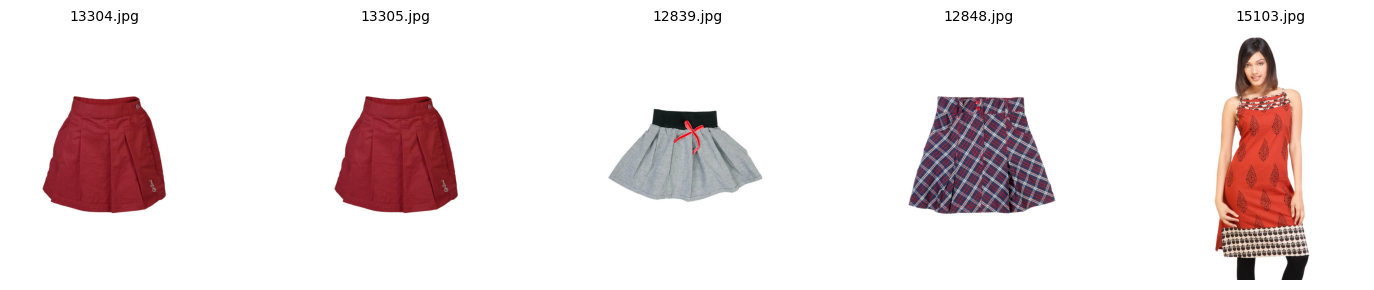

Query: blue sunglasses
  1: 17229.jpg (score=0.313)
  2: 17225.jpg (score=0.309)
  3: 17227.jpg (score=0.306)
  4: 1638.jpg (score=0.303)
  5: 16894.jpg (score=0.303)


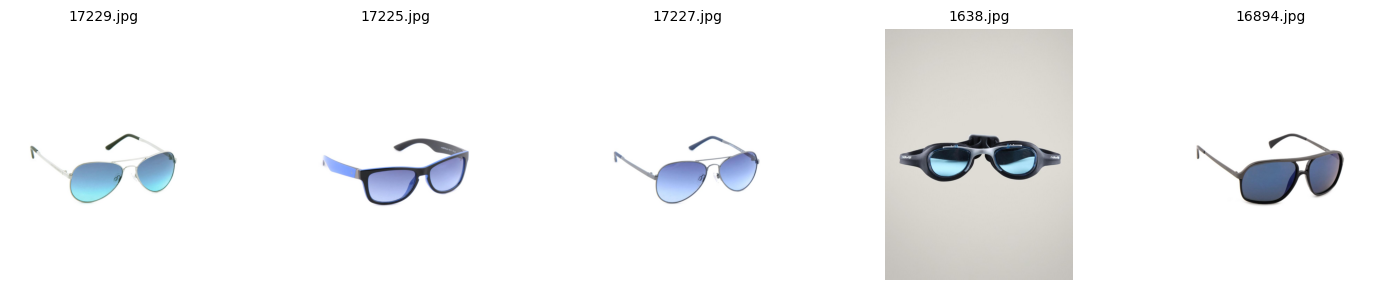

Query: mickey mouse
  1: 11359.jpg (score=0.284)
  2: 14924.jpg (score=0.268)
  3: 1847.jpg (score=0.265)
  4: 16824.jpg (score=0.263)
  5: 10988.jpg (score=0.263)


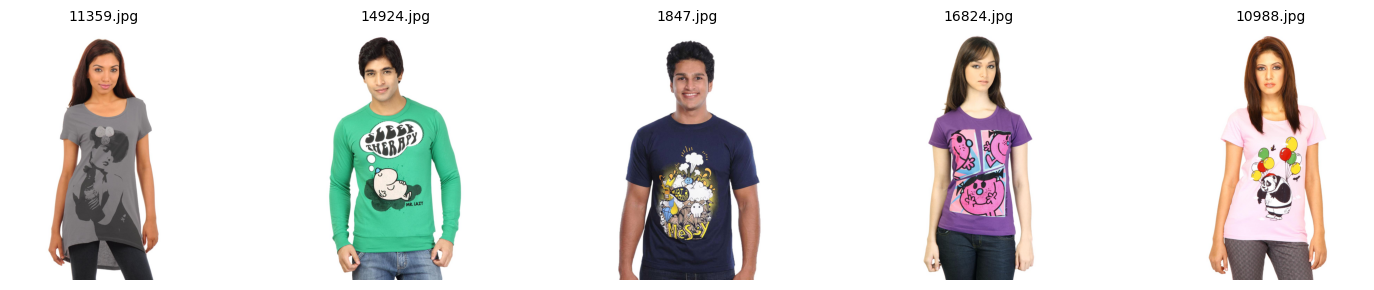

In [ ]:
test_queries = ["red skirt", "blue sunglasses", "mickey mouse"]

for query in test_queries:
    results = search_products(query, model, processor, image_embeddings, all_image_paths, top_k=5)
    # Загружаем изображения для визуализации
    imgs = [Image.open(path).convert('RGB') for path, _ in results]
    scores = [score for _, score in results]
    titles = [os.path.basename(path) for path, _ in results]
    print(f"Query: {query}")
    for i, (path, score) in enumerate(results):
        print(f"  {i+1}: {os.path.basename(path)} (score={score:.3f})")
        
    plot_images(imgs, titles=titles, scores=scores, cols=5, save_path=f"search_{query.replace(' ', '_')}.png")